In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [5]:
import polars as pl

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from scipy.stats import pearsonr
from plotly import express as px
import altair as alt
from pathlib import Path
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer


import importlib
import offline_historique
import read_data

importlib.reload(offline_historique)
from offline_historique import parse_historique_from_folder  # noqa: E402

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(100)

polars.config.Config

In [3]:
def complete_operations(df):
    return df.filter(
        pl.col("status_code").first().over("id") == "depot",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
    )


def complete_operations_pod(df):
    return df.filter(
        pl.col("status_code").first().over("id") == "areturn",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
    )

In [6]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [7]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
)
operations = (
    pl.read_parquet("data/cab_dfs/operations.parquet")
    .filter(pl.col("cab").is_in(cabs_inter))
    .filter(is_valid="V")
    .sort(
        pl.col("Heure_Syst_Oper").min().over("id"),
        pl.col("Heure_Syst_Oper"),
    )
)

In [8]:
print(fields.group_by("Produit_Niveau_Service").len().sort("len", descending=True))

shape: (3, 2)
┌────────────────────────┬────────┐
│ Produit_Niveau_Service ┆ len    │
│ ---                    ┆ ---    │
│ str                    ┆ u32    │
╞════════════════════════╪════════╡
│ Post Colis Prioritaire ┆ 195829 │
│                        ┆ 11     │
│ Colis-Tasdirsahel      ┆ 3      │
└────────────────────────┴────────┘


In [9]:
print(
    operations.filter(pl.col("status_code").first().over("id") != "depot")
)

shape: (13_838, 13)
┌───────────────┬──────────┬────────────────┬─────────────────────┬────────────────────────┬────────────────────────────────────────────┬────────────┬────────────────────────┬───────────┬───────────┬─────────┬─────────────┬──────────┐
│ cab           ┆ id       ┆ Date_operation ┆ Heure_Syst_Oper     ┆ Statut                 ┆ Agence                                     ┆ Agent_oper ┆ Etat                   ┆ Date_Etat ┆ Agent_maj ┆ ORIGINE ┆ status_code ┆ is_valid │
│ ---           ┆ ---      ┆ ---            ┆ ---                 ┆ ---                    ┆ ---                                        ┆ ---        ┆ ---                    ┆ ---       ┆ ---       ┆ ---     ┆ ---         ┆ ---      │
│ str           ┆ str      ┆ date           ┆ datetime[μs]        ┆ str                    ┆ str                                        ┆ i64        ┆ str                    ┆ str       ┆ str       ┆ str     ┆ str         ┆ str      │
╞═══════════════╪══════════╪════════════

In [10]:
34_561

34561

In [11]:
complete_operations = operations
print(complete_operations)

shape: (838_733, 13)
┌───────────────┬──────────┬────────────────┬─────────────────────┬────────────────┬────────────────────────────────────────────┬────────────┬──────────────────────┬──────────────────┬───────────┬─────────┬─────────────┬──────────┐
│ cab           ┆ id       ┆ Date_operation ┆ Heure_Syst_Oper     ┆ Statut         ┆ Agence                                     ┆ Agent_oper ┆ Etat                 ┆ Date_Etat        ┆ Agent_maj ┆ ORIGINE ┆ status_code ┆ is_valid │
│ ---           ┆ ---      ┆ ---            ┆ ---                 ┆ ---            ┆ ---                                        ┆ ---        ┆ ---                  ┆ ---              ┆ ---       ┆ ---     ┆ ---         ┆ ---      │
│ str           ┆ str      ┆ date           ┆ datetime[μs]        ┆ str            ┆ str                                        ┆ i64        ┆ str                  ┆ str              ┆ str       ┆ str     ┆ str         ┆ str      │
╞═══════════════╪══════════╪════════════════╪══════

In [12]:
log = (
    operations.filter(
        pl.col("status_code").first().over("id") == "depot",
        pl.col("status_code").last().over("id").is_in(["liv", "liv_ret"]),
        pl.col("status_code")
        .is_in(
            [
                "lev",
                # "recpt",
                # "aexp",
            ]
        )
        .not_(),
    )
    .rename(
        {
            "id": "case:concept:name",
            "status_code": "concept:name",
            "Heure_Syst_Oper": "time:timestamp",
        }
    )
    .to_pandas()
)

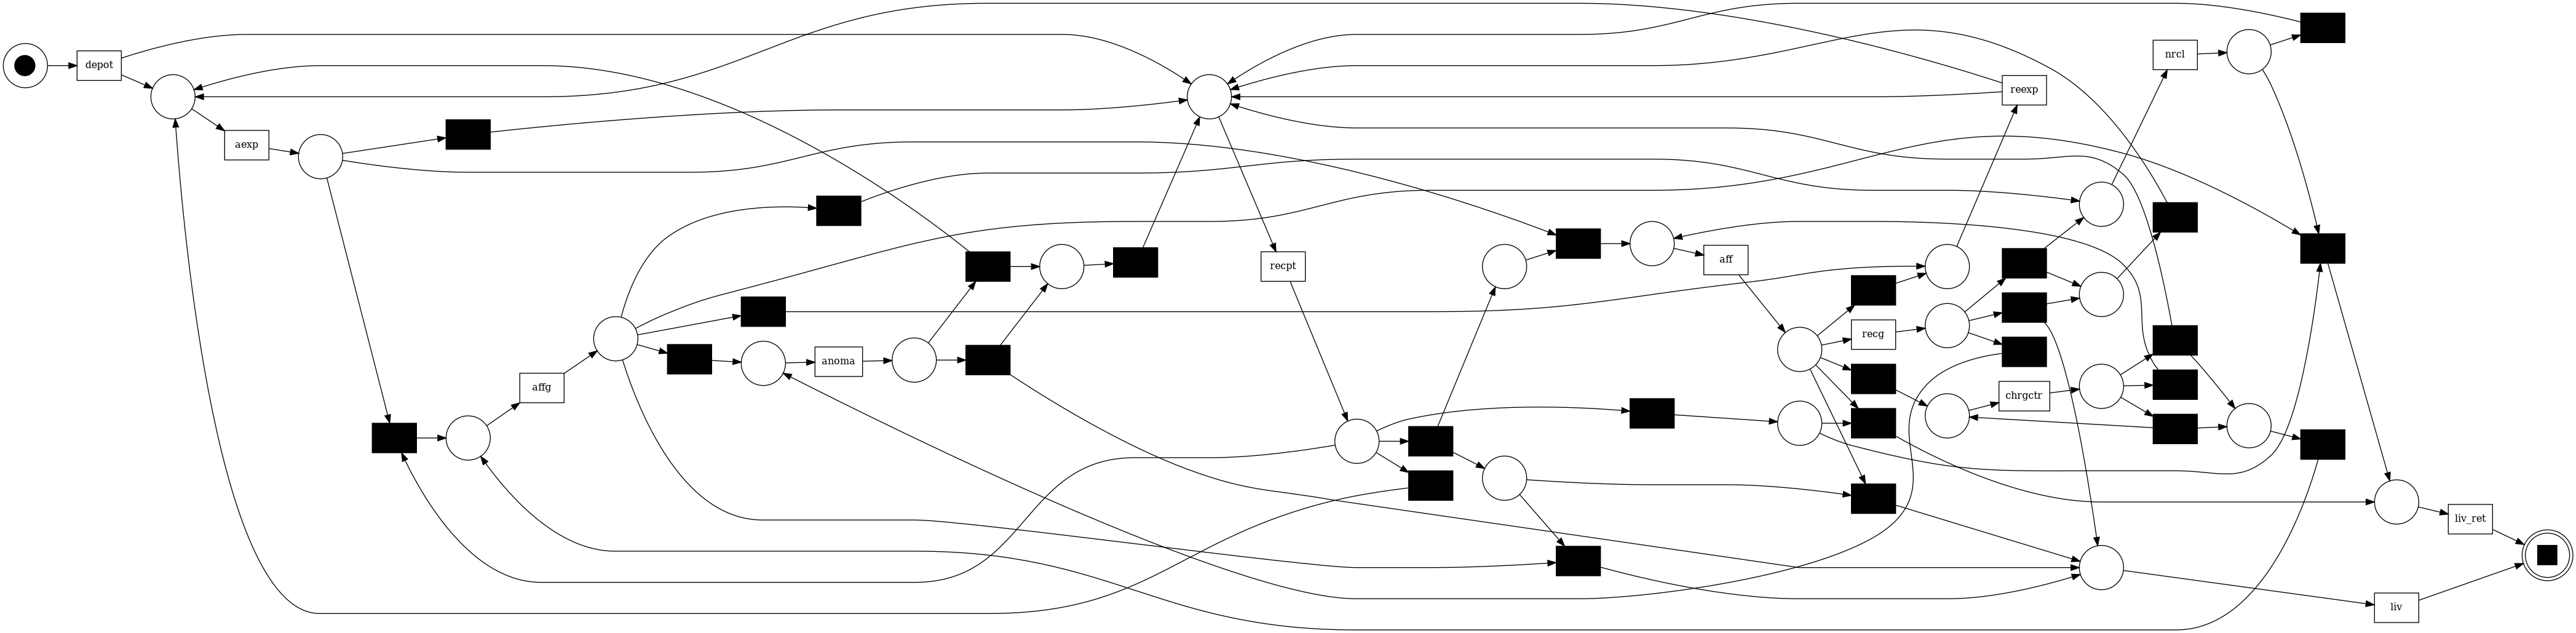

In [13]:
net, initial_marking, final_marking = pm4py.discover_petri_net_heuristics(log)
pm4py.view_petri_net(
    net,
    initial_marking,
    final_marking,
    # format="svg",
)

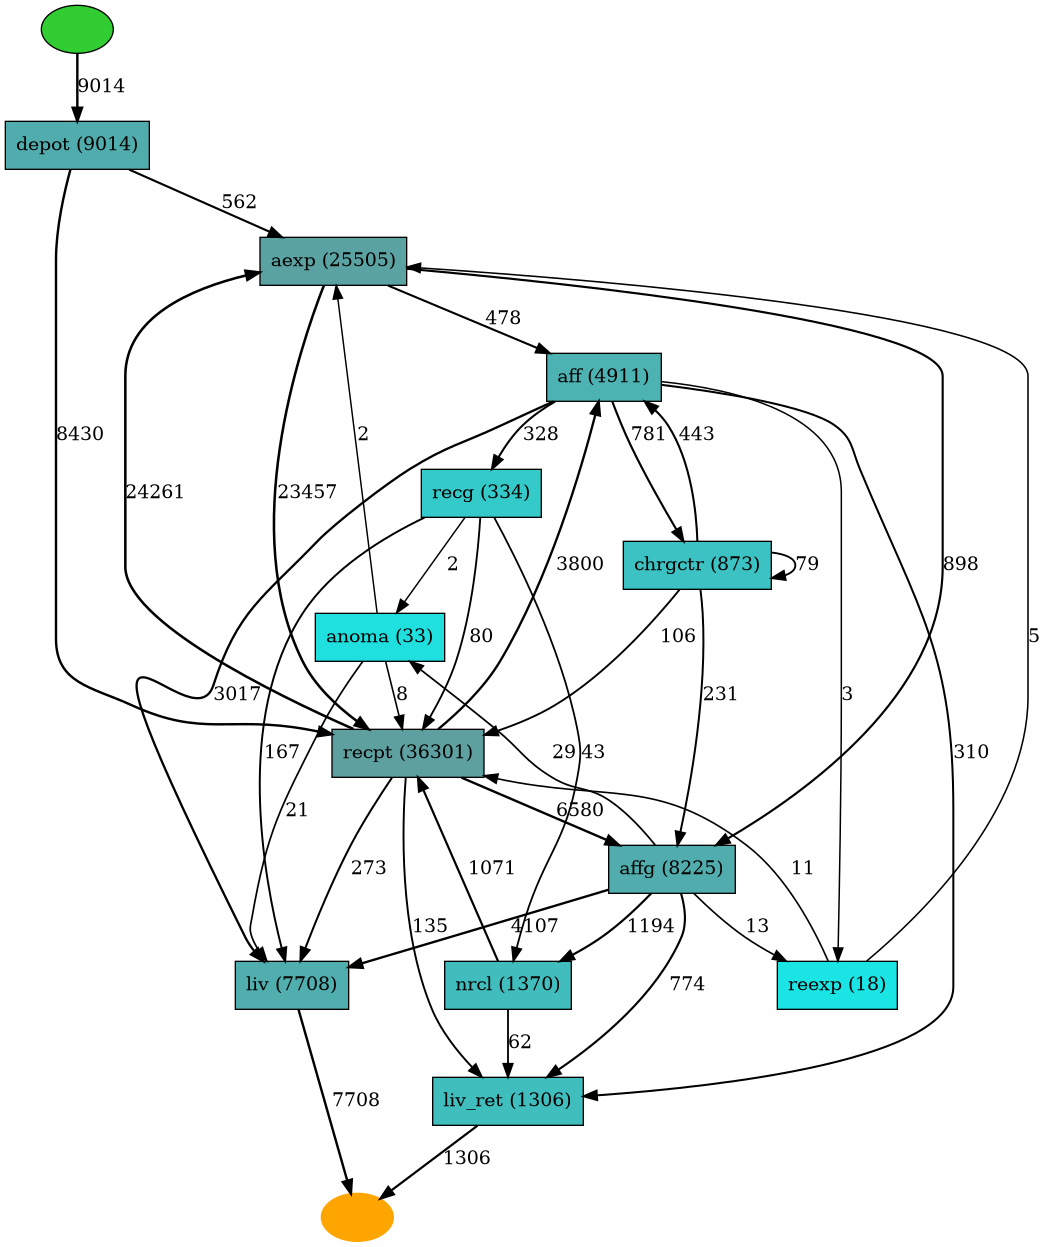

In [14]:
heuristics_net = pm4py.discover_heuristics_net(log)
pm4py.view_heuristics_net(heuristics_net)

In [21]:
print(len(log))                           # events
print(log['case:concept:name'].nunique()) # cases
print(log['concept:name'].nunique())      # activities

95598
9014
12


In [ ]:
variants = pm4py.get_variants(log)
top_10_variants = (
    pl.DataFrame(
        [(str(k), v) for k, v in variants.items()], ["variant", "count"], orient="row"
    )
    .sort("count", descending=True)
    .head(10)
)
top_10_variants.to_dicts()

[{'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aff', 'liv')",
  'count': 912},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'affg', 'liv')",
  'count': 785},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'affg', 'liv')",
  'count': 671},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aff', 'liv')",
  'count': 335},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'affg', 'liv')",
  'count': 210},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aff', 'liv')",
  'count': 198},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'affg', 'liv')",
  'count': 153},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aff', 'liv')",
  'count': 148},
 {'variant': "('depot', 'recpt', 'aexp', 'recpt', 'aexp', 'recpt', 'aexp', 'affg', 'liv')",
  'count': 119},
 {'variant': "('dep

In [ ]:
fitness = pm4py.fitness_token_based_replay(
    log,
    net,
    initial_marking,
    final_marking
)

In [18]:
heuristics_net.nodes

{'aexp': (node:aexp connections:{aff:[0.9979123173277662], affg:[0.9988876529477196], recpt:[0]}),
 'aff': (node:aff connections:{liv:[0.9996686547382373], liv_ret:[0.9967845659163987], recg:[0.9969604863221885], reexp:[0.75], chrgctr:[0]}),
 'affg': (node:affg connections:{anoma:[0.9666666666666667], liv:[0.9997565725413826], liv_ret:[0.9987096774193548], nrcl:[0.7855007473841554], reexp:[0.6875]}),
 'liv': (node:liv connections:{}),
 'liv_ret': (node:liv_ret connections:{}),
 'recg': (node:recg connections:{anoma:[0.6666666666666666], liv:[0.9940476190476191], nrcl:[0.9772727272727273], recpt:[0.9876543209876543]}),
 'reexp': (node:reexp connections:{aexp:[0.5714285714285714], recpt:[0.7692307692307693]}),
 'anoma': (node:anoma connections:{aexp:[0.6666666666666666], liv:[0.9545454545454546], recpt:[0.5454545454545454]}),
 'nrcl': (node:nrcl connections:{liv_ret:[0.9841269841269841], recpt:[0.8586296617519514]}),
 'recpt': (node:recpt connections:{aff:[0.9997369113391212], affg:[0.56

In [44]:
heuristics_net.__dict__.keys()

dict_keys(['net_name', 'nodes', 'dependency_matrix', 'dfg_matrix', 'dfg', 'performance_dfg', 'node_type', 'activities', 'start_activities', 'end_activities', 'activities_occurrences', 'default_edges_color', 'dfg_window_2', 'dfg_window_2_matrix', 'freq_triples', 'freq_triples_matrix', 'concurrent_activities', 'sojourn_times', 'min_dfg_occurrences', 'performance_matrix'])

In [ ]:
heuristics_net.dfg_matrix

['recpt',
 'aexp',
 'depot',
 'affg',
 'liv',
 'aff',
 'nrcl',
 'liv_ret',
 'chrgctr',
 'recg',
 'anoma',
 'reexp']


== Status meaning
=== French
- `depot`: depot
- `lev`: Levée envoi
- `recpt`: Reçu par
- `aexp`: Expédié vers
- `aff`: 	Mis en distribution
- `affg`: En instance au guichet
- `chrgctr`: Deuxième tentative pour complément d'adresse/ ou livraison
- `recg`: Avisé au guichet
- `nrcl`: Non réclamé
- `liv`: Livré
- `liv_ret`: Livraison retour
- `anoma`: Mis en rebus


=== English
- `depot`: the sender deposits the package at a site
- `lev`: the package is collected from sender by the postal service
- `recpt`: the package is received by site
- `aexp`: the package is forwarded to site
- `affg`: the package is being held at the post office awaiting pickup by the recipient
- `aff`: the package is put into distribution
- `chrgctr`: Second attempt for additional address information/or delivery
- `recg`: the recipient has been notified that the item is available for pickup at the counter
- `nrcl`: the package is not claimed, these packages stay in storage at the site for a defined period before being returned to sender. If the sender also doesn't claim it, it's moved to long-term storage
- `liv`: the package is successfully delivered
- `liv_ret`: the package is successfully returned to sender
- `anoma`: the package is disposed of
